# 1️. Imports & Load Data

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())
print(df.shape)
print(df.describe())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

# 2. Data Cleaning

In [93]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove duplicates
print(f"Duplicate Rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Remove cancelled invoices (starting with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]

# Remove invalid transactions
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature engineering
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Reset index
df = df.reset_index(drop=True)

print("Rows:", len(df))
print("Customers:", df['CustomerID'].nunique())
print("Revenue:", df['TotalSpend'].sum())

Duplicate Rows: 5225
Rows: 392692
Customers: 4338
Revenue: 8887208.894000001


# 3. Save Clean Data

In [96]:
df.to_csv("Cleaned_Online_Retail.csv", index=False)

# 4. RFM Feature Engineering

In [97]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print(rfm.head())
print(rfm.describe())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2048.688081
std     1721.808492   100.014169     7.697998    8985.230220
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     306.482500
50%    15299.500000    51.000000     2.000000     668.570000
75%    16778.750000   142.000000     5.000000    1660.597500
max    18287.000000   374.000000   209.000000  280206.020000


# 5. Scaling Features

In [98]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)



# 6. Elbow Method (Optimal Clusters)

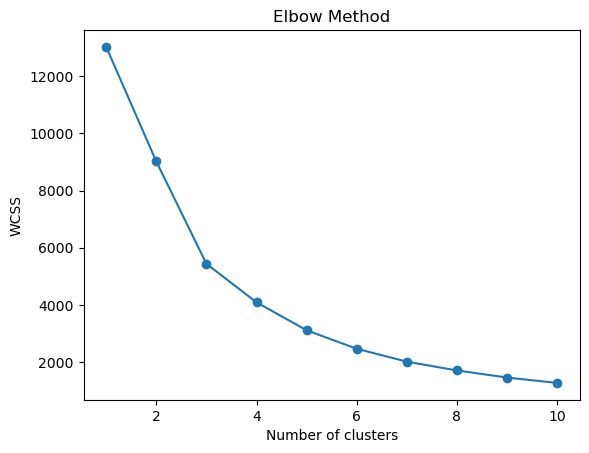

In [99]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# 7. K-Means Clustering

In [100]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 8. Cluster Profiling

In [101]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1353.625312
1        248.075914   1.552015     478.848773
2          7.384615  82.538462  127187.959231
3         15.500000  22.333333   12690.500392


# 9. Segment Mapping

In [102]:
cluster_map = {
    0: "Occasional Customers",
    1: "At-Risk Customers",
    2: "Champions",
    3: "Loyal Customers"
}

rfm['Segment'] = rfm['Cluster'].map(cluster_map)

print(rfm['Segment'].value_counts())


Segment
Occasional Customers    3054
At-Risk Customers       1067
Loyal Customers          204
Champions                 13
Name: count, dtype: int64


# 10. Business Insights

In [103]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print(segment_revenue)

Segment
Occasional Customers    4133971.703
Loyal Customers         2588862.080
Champions               1653443.470
At-Risk Customers        510931.641
Name: Monetary, dtype: float64


# 11. Exporting RFM 

In [104]:
rfm.to_csv("Customer_RFM.csv", index=False)